Dataset Type: <class 'pandas.core.frame.DataFrame'>
Dataset Head:    user  activity     timestamp         x          y         z
0    33         1  4.910596e+13 -0.694638  12.680544  0.503953
1    33         1  4.910606e+13  5.012288  11.264028  0.953424
2    33         1  4.910611e+13  4.903325  10.882658 -0.081722
3    33         1  4.910622e+13 -0.612916  18.496431  3.023717
4    33         1  4.910633e+13 -1.184970  12.108489  7.205164
Train Features:
[[ 0.5720546   9.80665    -0.53119355]
 [-0.         10.18802    -0.5720546 ]
 [-0.23154591  9.847511   -0.6946377 ]
 [ 0.14982383 10.079058   -0.50395286]
 [ 0.14982383 10.147159   -0.61291564]
 [ 0.61291564  9.956474   -0.6946377 ]
 [ 0.10896278  9.997335   -0.50395286]
 [-0.10896278 10.038197   -0.53119355]
 [-0.08172209 10.119919   -0.38136974]
 [ 0.313268    9.997335   -0.61291564]]
X_train shape: (7421, 200, 3)
y_train shape: (7421,)

TEST 1: NUMERICAL GRADIENT CHECK FOR NUMPY RNN
---Gradient Check---
 Relative Error: 0.00000007

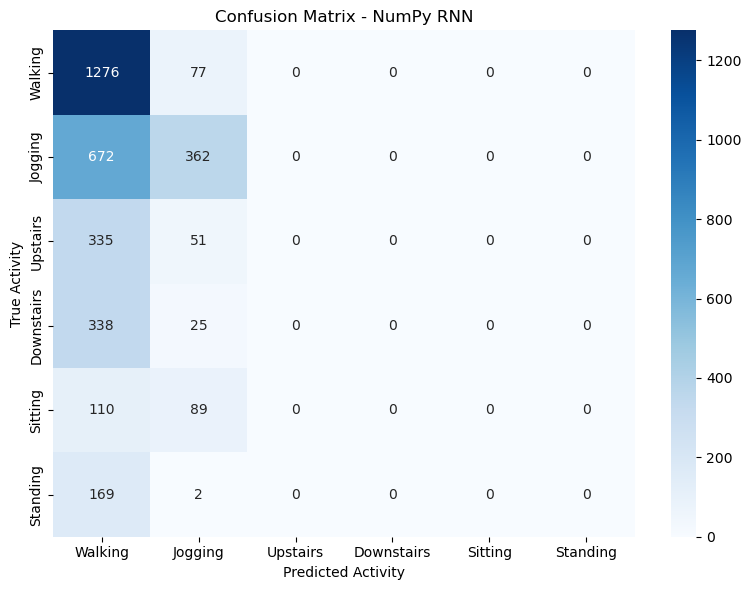


Statring PyTorch Training  PyTorch LSTM
Epoch 01/15 | Train Loss: 1.1424
Epoch 02/15 | Train Loss: 0.7994
Epoch 03/15 | Train Loss: 0.6974
Epoch 04/15 | Train Loss: 0.6104
Epoch 05/15 | Train Loss: 0.6020
Epoch 06/15 | Train Loss: 0.6036
Epoch 07/15 | Train Loss: 0.5359
Epoch 08/15 | Train Loss: 0.4881
Epoch 09/15 | Train Loss: 0.4511
Epoch 10/15 | Train Loss: 0.3889
Epoch 11/15 | Train Loss: 0.3572
Epoch 12/15 | Train Loss: 0.3284
Epoch 13/15 | Train Loss: 0.3059
Epoch 14/15 | Train Loss: 0.2698
Epoch 15/15 | Train Loss: 0.2348
PyTorch Total Training Time PyTorch LSTM: 21.21 seconds

--- Evaluation Results for PyTorch LSTM ---
Accuracy: 75.93%
Macro-F1 Score: 0.6957

Per-Class F1 Scores:
  Walking: 0.8337
  Jogging: 0.8673
  Upstairs: 0.4956
  Downstairs: 0.3798
  Sitting: 0.8643
  Standing: 0.7337


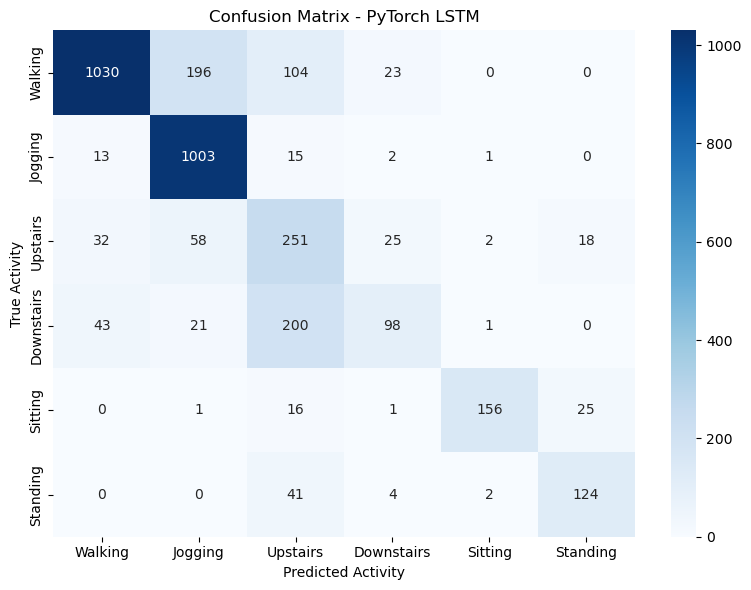


Statring PyTorch Training  PyTorch BiLSTM
Epoch 01/15 | Train Loss: 1.2630
Epoch 02/15 | Train Loss: 0.8565
Epoch 03/15 | Train Loss: 0.7926
Epoch 04/15 | Train Loss: 0.7028
Epoch 05/15 | Train Loss: 0.5978
Epoch 06/15 | Train Loss: 0.5654
Epoch 07/15 | Train Loss: 0.5179
Epoch 08/15 | Train Loss: 0.4886
Epoch 09/15 | Train Loss: 0.4113
Epoch 10/15 | Train Loss: 0.3846
Epoch 11/15 | Train Loss: 0.3526
Epoch 12/15 | Train Loss: 0.3181
Epoch 13/15 | Train Loss: 0.3220
Epoch 14/15 | Train Loss: 0.2793
Epoch 15/15 | Train Loss: 0.2460
PyTorch Total Training Time PyTorch BiLSTM: 39.30 seconds

--- Evaluation Results for PyTorch BiLSTM ---
Accuracy: 80.18%
Macro-F1 Score: 0.7416

Per-Class F1 Scores:
  Walking: 0.9057
  Jogging: 0.8702
  Upstairs: 0.4737
  Downstairs: 0.5287
  Sitting: 0.8674
  Standing: 0.8035


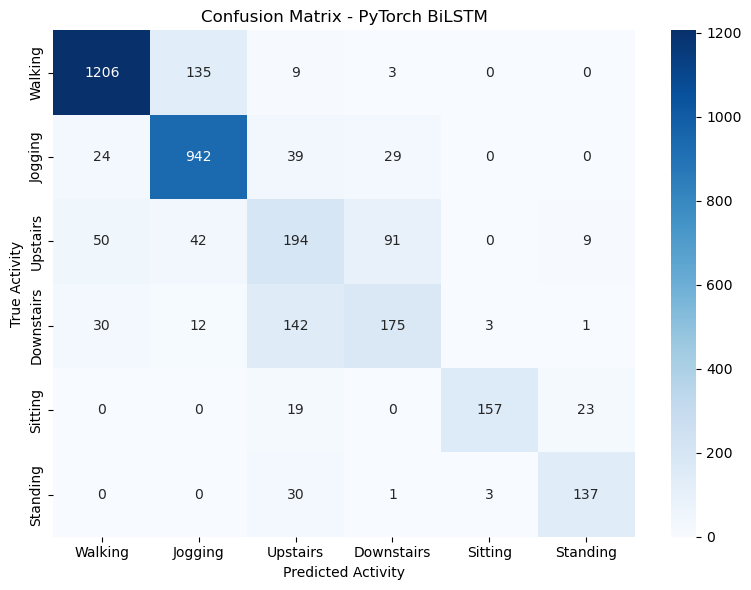


1. NumPy Simple RNN : Time = 41.40s | Accuracy = 46.72% | Macro-F1 = 0.1736
2. PyTorch LSTM     : Time = 21.21s | Accuracy = 75.93% | Macro-F1 = 0.6957
3. PyTorch BiLSTM   : Time = 39.30s | Accuracy = 80.18% | Macro-F1 = 0.7416


In [1]:
import time
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
from torch.utils.data import TensorDataset, DataLoader

np.random.seed(42)
try:
    FILE_PATH = Path(__file__).resolve().parent
except NameError:
    FILE_PATH = Path.cwd()

ACTIVITY_MAP = {
    "Walking": 0,
    "Jogging": 1,
    "Upstairs": 2,
    "Downstairs": 3,
    "Sitting": 4,
    "Standing": 5,
}
INT_TO_ACTIVITY = {v: k for k, v in ACTIVITY_MAP.items()}


def softmax(x):
    exps = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exps / np.sum(exps, axis=1, keepdims=True)


class NumPyRNN:
    def __init__(self, input_dim, hidden_dim, output_dim, learning_rate=0.01):
        self.learning_rate = learning_rate
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim
        self.learning_rate = learning_rate

        scale = 0.01
        self.Wxh = np.random.randn(input_dim, hidden_dim) * scale
        self.Whh = np.random.randn(hidden_dim, hidden_dim) * scale
        self.Wyh = np.random.randn(hidden_dim, output_dim) * scale

        self.bh = np.zeros(hidden_dim)
        self.by = np.zeros(output_dim)

    def forward(self, X):

        batch_size = X.shape[0]
        window_length = X.shape[1]

        hs = {}
        hs[-1] = np.zeros(shape=(batch_size, self.hidden_dim))

        for i in range(window_length):
            h = np.tanh(
                X[:, i] @ self.Wxh + hs[i - 1] @ self.Whh + self.bh
            )  # dim: (batch_size, hidden_dim)
            hs[i] = h

        logits = hs[window_length - 1] @ self.Wyh + self.by
        probs = softmax(logits)
        return probs, (X, hs, probs)

    @staticmethod
    def cross_entropy_loss(probs, y_true):
        epsilon = 1e-12
        n = probs.shape[0]
        correct_probs = probs[np.arange(n), y_true]
        loss = -np.mean(np.log(correct_probs + epsilon))
        return loss

    def backward(self, y_true, cache):
        X, hs, probs = cache

        num_sample = X.shape[0]
        window_length = X.shape[1]

        dlogits = probs.copy()
        dlogits[np.arange(num_sample), y_true] -= 1
        dlogits /= num_sample

        h_final = hs[window_length - 1]
        dWyh = h_final.T @ dlogits
        dby = np.sum(dlogits, axis=0)
        dh_next = dlogits @ self.Wyh.T

        dWxh = np.zeros_like(self.Wxh)
        dWhh = np.zeros_like(self.Whh)
        dbh = np.zeros_like(self.bh)

        for t in reversed(range(window_length)):
            dtanh = (1 - hs[t] ** 2) * dh_next
            dbh += np.sum(dtanh, axis=0)
            dWxh += X[:, t].T @ dtanh
            dWhh += hs[t - 1].T @ dtanh
            dh_next = dtanh @ self.Whh.T

        gradients = {"dWxh": dWxh, "dWhh": dWhh, "dWyh": dWyh, "dby": dby, "dbh": dbh}

        return gradients

    def update_params(self, gradients, max_grad_norm):
        for key in gradients:
            gradients[key] = np.clip(gradients[key], -max_grad_norm, max_grad_norm)

        self.Whh -= self.learning_rate * gradients["dWhh"]
        self.Wxh -= self.learning_rate * gradients["dWxh"]
        self.Wyh -= self.learning_rate * gradients["dWyh"]
        self.bh -= self.learning_rate * gradients["dbh"]
        self.by -= self.learning_rate * gradients["dby"]


def create_windows(data, window_size=200, step_size=100):
    """
    creates windows for the dataset.
    returns X and Y as np arrays.
    """
    X_all = []
    Y_all = []
    for _, group in data.groupby("user"):
        X_labels = []
        Y_labels = []

        features = group[["x", "y", "z"]].values
        activities = group["activity"].values
        for i in range(0, len(group) - window_size + 1, step_size):
            dominant_label = Counter(activities[i : i + window_size]).most_common(1)[0][
                0
            ]
            X_labels.append(features[i : i + window_size])
            Y_labels.append(dominant_label)

        if len(X_labels) > 0:
            X_all.append(np.array(X_labels))
            Y_all.append(np.array(Y_labels))

    X = np.concatenate(X_all, axis=0)
    Y = np.concatenate(Y_all, axis=0)
    return X, Y


def load_dataset():

    dataset_path = FILE_PATH / "dataset" / "WISDM_ar_v1.1_cleaned.csv"
    dataset = pd.read_csv(
        dataset_path,
        dtype={"user": int, "timestamp": float, "x": float, "y": float, "z": float},
    )
    print("Dataset Type: " + str(type(dataset)))

    # mapping activities to integers
    dataset["activity"] = dataset["activity"].map(ACTIVITY_MAP)

    print("Dataset Head: " + str(dataset.head()))

    train_dataset = dataset[(dataset["user"]) <= 25].copy()
    test_dataset = dataset[dataset["user"] > 25].copy()

    train_features = train_dataset[["x", "y", "z"]].values
    test_features = test_dataset[["x", "y", "z"]].values

    print("Train Features:\n" + str(train_features[0:10]))

    # standardizing the data
    mean = np.mean(train_features, axis=0)
    std = np.std(train_features, axis=0) + 1e-8  # 1e-8 prevents division by zero

    train_dataset[["x", "y", "z"]] = (train_features - mean) / std

    test_dataset[["x", "y", "z"]] = (test_features - mean) / std

    return dataset, train_dataset, test_dataset


def check_gradient_numerical(model, X_sample, y_sample, epsilon=1e-7):
    print("---Gradient Check---")

    probs, cache = model.forward(X_sample)
    analytic_grads = model.backward(y_sample, cache)
    dWxh_analytic = analytic_grads["dWxh"]

    dWxh_num = np.zeros_like(model.Wxh)

    for i in range(model.Wxh.shape[0]):
        for j in range(model.Wxh.shape[1]):
            orig_val = model.Wxh[i, j]

            model.Wxh[i, j] = orig_val + epsilon
            probs_plus, _ = model.forward(X_sample)
            loss_plus = model.cross_entropy_loss(probs_plus, y_sample)

            model.Wxh[i, j] = orig_val - epsilon
            probs_minus, _ = model.forward(X_sample)
            loss_minus = model.cross_entropy_loss(probs_minus, y_sample)

            dWxh_num[i, j] = (loss_plus - loss_minus) / (2 * epsilon)

            model.Wxh[i, j] = orig_val

    numerator = np.linalg.norm(dWxh_analytic - dWxh_num)
    denominator = np.linalg.norm(dWxh_analytic) + np.linalg.norm(dWxh_num) + 1e-12
    relative_error = numerator / denominator

    print(f" Relative Error: {relative_error:.8f}")
    if relative_error < 1e-5:
        print("Gradient is ✅")
    else:
        print("Gradient is ❌")


def local_Numpy_vs_nnRnn_check(
    numpy_model, input_dim, hidden_dim, batch_size=2, window_len=10
):
    print("--- local PyTorch vs NumPy Check---")

    pytorch_rnn = nn.RNN(input_size=input_dim, hidden_size=hidden_dim, batch_first=True)

    with torch.no_grad():
        pytorch_rnn.weight_ih_l0.copy_(torch.from_numpy(numpy_model.Wxh.T))
        pytorch_rnn.weight_hh_l0.copy_(torch.from_numpy(numpy_model.Whh.T))
        pytorch_rnn.bias_ih_l0.copy_(torch.from_numpy(numpy_model.bh))
        pytorch_rnn.bias_hh_l0.zero_()

    X_test_np = np.random.randn(batch_size, window_len, input_dim)
    X_test_torch = torch.from_numpy(X_test_np).float()

    _, cache = numpy_model.forward(X_test_np)
    out_numpy = cache[1][window_len - 1]

    out_torch, _ = pytorch_rnn(X_test_torch)
    out_torch_last = out_torch[:, -1, :].detach().numpy()

    diff = np.max(np.abs(out_numpy - out_torch_last))
    print(f"Max difference between NumPy and PyTorch outputs: {diff:.8f}")
    if diff < 1e-5:
        print("✅ Success! NumPy model output matches PyTorch nn.RNN perfectly.")
    else:
        print("❌ Warning! Significant difference detected between outputs.")


class PyTorchSimpleRNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.rnn = nn.RNN(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, _ = self.rnn(x)
        last_out = out[:, -1, :]
        return self.fc(last_out)


class PyTorchLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, _ = self.lstm(x)
        last_out = out[:, -1, :]
        return self.fc(last_out)


class PyTorchBiLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, x):
        out, _ = self.lstm(x)
        last_out = out[:, -1, :]
        return self.fc(last_out)


def evaluate_and_report(y_true, y_pred, model_name="Model"):

    # 1. Calculate overall accuracy
    acc = accuracy_score(y_true, y_pred)

    # 2. Calculate macro-F1 (unweighted mean of F1 for all classes)
    macro_f1 = f1_score(y_true, y_pred, average="macro")

    # 3. Calculate per-class F1 to see where the model performs poorly
    class_f1 = f1_score(y_true, y_pred, average=None)

    print(f"\n--- Evaluation Results for {model_name} ---")
    print(f"Accuracy: {acc * 100:.2f}%")
    print(f"Macro-F1 Score: {macro_f1:.4f}")

    activity_names = [
        "Walking",
        "Jogging",
        "Upstairs",
        "Downstairs",
        "Sitting",
        "Standing",
    ]
    print("\nPer-Class F1 Scores:")
    for name, f1 in zip(activity_names, class_f1):
        print(f"  {name}: {f1:.4f}")

    # 4. Generate and plot Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=activity_names,
        yticklabels=activity_names,
    )
    plt.title(f"Confusion Matrix - {model_name}")
    plt.ylabel("True Activity")
    plt.xlabel("Predicted Activity")
    plt.tight_layout()
    plt.show()

    return acc, macro_f1, cm


def train_numpy_rnn(
    model, X_train, y_train, X_test, y_test, epochs=15, batch_size=64, max_grad_norm=5.0
):
    print("\n" + "=" * 60)
    print("Statring Numpy Training")
    print("=" * 60)

    start_time = time.time()
    num_samples = X_train.shape[0]

    for epoch in range(epochs):
        indices = np.arange(num_samples)
        np.random.shuffle(indices)
        X_shuffled = X_train[indices]
        y_shuffled = y_train[indices]

        epoch_loss = 0.0
        num_batches = int(np.ceil(num_samples / batch_size))

        for b in range(num_batches):
            start_idx = b * batch_size
            end_idx = min(start_idx + batch_size, num_samples)

            X_batch = X_shuffled[start_idx:end_idx]
            y_batch = y_shuffled[start_idx:end_idx]

            probs, cache = model.forward(X_batch)
            loss = model.cross_entropy_loss(probs, y_batch)
            epoch_loss += loss * (end_idx - start_idx)

            grads = model.backward(y_batch, cache)
            model.update_params(grads, max_grad_norm)

        epoch_loss /= num_samples
        print(f"Epoch {epoch+1:02d}/{epochs:02d} | Train Loss: {epoch_loss:.4f}")

    train_time = time.time() - start_time
    print(f"Numpy Total Training Time: {train_time:.2f} seconds")

    test_samples = X_test.shape[0]
    test_batches = int(np.ceil(test_samples / batch_size))
    y_pred_list = []

    for b in range(test_batches):
        start_idx = b * batch_size
        end_idx = min(start_idx + batch_size, test_samples)
        X_batch = X_test[start_idx:end_idx]
        probs, _ = model.forward(X_batch)
        y_pred_list.append(np.argmax(probs, axis=1))

    y_pred = np.concatenate(y_pred_list, axis=0)
    acc, macro_f1, cm = evaluate_and_report(y_test, y_pred, "NumPy RNN")
    return train_time, acc, macro_f1


def train_pytorch_model(
    model,
    X_train,
    y_train,
    X_test,
    y_test,
    epochs=15,
    batch_size=64,
    lr=0.005,
    model_name="PyTorch Model",
):
    print("\n" + "=" * 60)
    print(f"Statring PyTorch Training  {model_name}")
    print("=" * 60)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    X_train_tensor = torch.from_numpy(X_train).float()
    y_train_tensor = torch.from_numpy(y_train).long()
    X_test_tensor = torch.from_numpy(X_test).float()

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    start_time = time.time()
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            epoch_loss += loss.item() * X_batch.size(0)

        epoch_loss /= len(train_dataset)
        print(f"Epoch {epoch+1:02d}/{epochs:02d} | Train Loss: {epoch_loss:.4f}")

    train_time = time.time() - start_time
    print(f"PyTorch Total Training Time {model_name}: {train_time:.2f} seconds")

    model.eval()
    with torch.no_grad():
        test_outputs = []
        num_test = X_test_tensor.size(0)
        test_batches = int(np.ceil(num_test / batch_size))
        for b in range(test_batches):
            start_idx = b * batch_size
            end_idx = min(start_idx + batch_size, num_test)
            out = model(X_test_tensor[start_idx:end_idx])
            test_outputs.append(torch.argmax(out, dim=1).numpy())

        y_pred = np.concatenate(test_outputs, axis=0)

    acc, macro_f1, cm = evaluate_and_report(y_test, y_pred, model_name)
    return train_time, acc, macro_f1


def main():
    # Load the dataset
    dataset, train_dataset, test_dataset = load_dataset()

    # Create overlapping windows for training and testing sets
    X_train, y_train = create_windows(train_dataset)
    X_test, y_test = create_windows(test_dataset)
    print("X_train shape:", X_train.shape)
    print("y_train shape:", y_train.shape)

    # Define hyper-parameters for our test models
    input_dim = X_train.shape[2]  # 3 features (x, y, z acceleration)
    hidden_dim = 32  # Small hidden size for fast testing
    output_dim = 6  # 6 human activity classes
    learning_rate = 0.01

    # Initialize the custom NumPy RNN model
    numpy_model = NumPyRNN(
        input_dim, hidden_dim, output_dim, learning_rate=learning_rate
    )

    # TEST 1: Numerical Gradient Check (Section 2 Requirement)
    print("\n" + "=" * 60)
    print("TEST 1: NUMERICAL GRADIENT CHECK FOR NUMPY RNN")
    print("=" * 60)
    check_gradient_numerical(numpy_model, X_train[:2], y_train[:2])

    # TEST 2: Sanity Check with PyTorch nn.RNN (Section 3 Requirement)
    print("\n" + "=" * 60)
    print("TEST 2: NUMPY vs PYTORCH")
    print("=" * 60)
    local_Numpy_vs_nnRnn_check(
        numpy_model, input_dim, hidden_dim, batch_size=2, window_len=X_train.shape[1]
    )

    # Pytorch training and testing
    numpy_model = NumPyRNN(input_dim, hidden_dim, output_dim, learning_rate=0.01)
    time_np, acc_np, f1_np = train_numpy_rnn(
        numpy_model, X_train, y_train, X_test, y_test, epochs=15
    )

    # LSTM training and testing
    lstm_model = PyTorchLSTM(input_dim, hidden_dim, output_dim)
    time_lstm, acc_lstm, f1_lstm = train_pytorch_model(
        lstm_model,
        X_train,
        y_train,
        X_test,
        y_test,
        epochs=15,
        model_name="PyTorch LSTM",
    )

    # BiLSTM training and testing
    bilstm_model = PyTorchBiLSTM(input_dim, hidden_dim, output_dim)
    time_bilstm, acc_bilstm, f1_bilstm = train_pytorch_model(
        bilstm_model,
        X_train,
        y_train,
        X_test,
        y_test,
        epochs=15,
        model_name="PyTorch BiLSTM",
    )

    print("\n" + "=" * 70)
    print("=" * 70)
    print(
        f"1. NumPy Simple RNN : Time = {time_np:.2f}s | Accuracy = {acc_np*100:.2f}% | Macro-F1 = {f1_np:.4f}"
    )
    print(
        f"2. PyTorch LSTM     : Time = {time_lstm:.2f}s | Accuracy = {acc_lstm*100:.2f}% | Macro-F1 = {f1_lstm:.4f}"
    )
    print(
        f"3. PyTorch BiLSTM   : Time = {time_bilstm:.2f}s | Accuracy = {acc_bilstm*100:.2f}% | Macro-F1 = {f1_bilstm:.4f}"
    )
    print("=" * 70)


if __name__ == "__main__":
    main()
